In [32]:
import torch
import numpy as np


In [33]:
# step 1 : use a paceholder for transformer block
# step2: use a placeholder for layer normalization
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [38]:
import torch.nn as nn
class dummygpt(nn.Module):
    def __init__(self,cgf):
        super().__init__()
        self.token_emb=nn.Embedding(cgf['vocab_size'],cgf['emb_dim'])
        self.pos_emb=nn.Embedding(cgf['context_length'],cgf['emb_dim'])
        self.drop_emb=nn.Dropout(cgf['drop_rate'])

        # use placeholder for layernorm
        self.trf_blocks=nn.Sequential(*[DummyTransformerBlock(cgf) for _ in range(cgf['n_layers'])])

        # use a placholder for layernorm
        self.final_norm=DummyLayerNorm(cgf['emb_dim'])
        self.out_head=nn.Linear(cgf['emb_dim'],cgf['vocab_size'],bias=False)

    def forward(self,in_idx):
        batch_size,seq_lenght=in_idx.shape
        token_embbed=self.token_emb(in_idx)
        pos_embbed=self.pos_emb(torch.arange(seq_lenght))
        x=token_embbed+pos_embbed
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cgf):
        
        super().__init__()

    # a simple placeholder
    def forward(self,x):
        # it retrurn its input
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self,x):
        # return its input
        return x

        

## now prepare the input datata and intailize a new gpt model to illusread its usage


In [39]:
# step 1: TOKENZATION
import tiktoken
tokenizer=tiktoken.encoding_for_model('gpt-4o')

batch=[]
txt1='Every effort moves you'
txt2='Every day holds a'
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[15745,  6942, 19523,   481],
        [15745,  2163, 18305,   261]])


In [40]:
# step 2 : cratr7itng an intace of dummygptmodel
torch.manual_seed(123)
model=dummygpt(GPT_CONFIG_124M)
logits=model(batch)
print(logits.shape)
print(logits)


torch.Size([2, 4, 50257])
tensor([[[-0.3388,  0.2594, -0.3170,  ..., -1.9058,  0.0265,  0.1712],
         [-0.7077,  1.8087, -0.7415,  ...,  0.4567, -0.3985, -0.3291],
         [ 0.8687,  0.4867,  1.5297,  ...,  1.6327,  1.2669, -1.1252],
         [-0.8554,  0.4356, -0.4397,  ...,  2.7628,  1.0190, -0.3655]],

        [[-0.7805,  0.1809, -0.4489,  ..., -1.6959,  0.1992,  0.0304],
         [-0.4472,  0.3676, -0.8550,  ...,  0.2767,  1.2041,  0.4816],
         [ 0.3561, -0.4490,  1.0373,  ...,  0.4671,  0.2866,  0.1540],
         [-0.8558,  0.7030, -1.0403,  ...,  1.7788,  0.3470,  0.1882]]],
       grad_fn=<UnsafeViewBackward0>)


In [41]:
# the out put tensor has two rows corresponding to the two text sample each text sample consisit of 4 tokens 
# each torkens is a 50257 dimention vector which match the sizwe of tokennizer vocabulary


# GPT ARCHETECTURE PART 2 : LAYER NORMALIZATION

In [42]:
# exaple
torch.manual_seed(123)
batch_exaple=torch.randn(2,5)
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_exaple)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [43]:
# mean and varienc
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print(mean)
print(var)

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [44]:
out_norm=(out-mean)/torch.sqrt(var)
mean1=out_norm.norm(dim=-1,keepdim=True)
var1=out_norm.var(dim=-1,keepdim=True)
print(mean1)
print(var1)

tensor([[2.2361],
        [2.2361]], grad_fn=<LinalgVectorNormBackward0>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [45]:
print(out_norm)

tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)


In [46]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [47]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_exaple)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# GPT  ARCTICHURE PART3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION

In [48]:
import torch
import torch.nn as nn
import pandas as pd

In [49]:
class GElu(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.44715*torch.pow(x,3))))
        

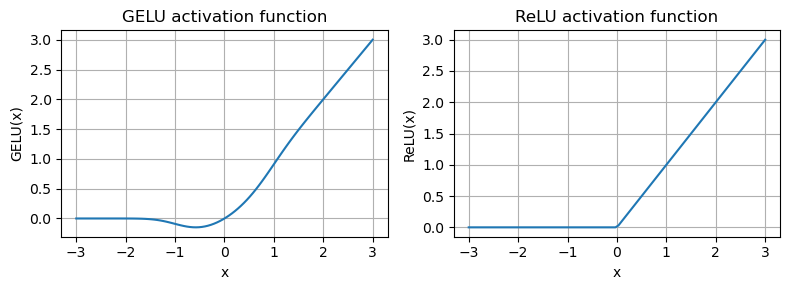

In [50]:
import matplotlib.pyplot as plt
gelu,relu=GElu(),nn.ReLU()

# some sample datat
x=torch.linspace(-3,3,100)
y_gelu,y_relu=gelu(x),relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu,y_relu],["GELU", "ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f'{label} activation function')
    plt.xlabel('x')

    plt.ylabel(f'{label}(x)')
    plt.grid(True)

plt.tight_layout()
plt.show()

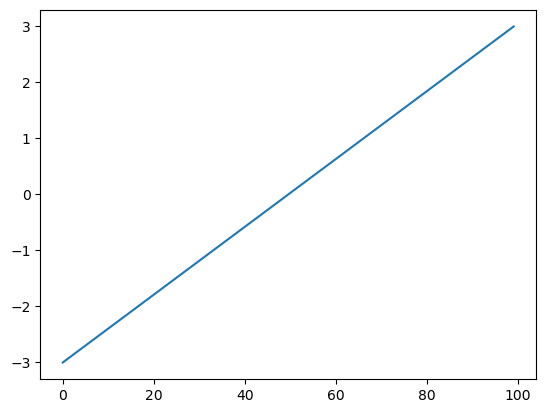

In [51]:
plt.plot(x)

In [52]:
# feddforward neural network
class feedforward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(nn.Linear(cfg['emb_dim'],4*cfg['emb_dim']),
                                 GElu(),
                                 nn.Linear(4*cfg['emb_dim'],cfg['emb_dim']),
                                 )

    def forward(self,x):
        return self.layers(x)
        

In [53]:
print(GPT_CONFIG_124M['emb_dim'])

768


In [54]:
# use gelu actvition function to imlemanet the small neural network module feedforward that we will 

In [55]:
ffn=feedforward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out1=ffn(x)
print(out1.shape)

torch.Size([2, 3, 768])


In [64]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

batch=torch.stack((inputs,inputs),dim=0)
print(batch.shape)
torch.manual_seed(123)
context_length=batch.shape[1]

torch.Size([2, 6, 3])


# SHORTCUT CONNECTION

In [65]:
class exapledeepnuralnetwork(nn.Module):
    def __init__(self,layer_size,use_shortcut):
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_size[0],layer_size[1]),GElu()),
            nn.Sequential(nn.Linear(layer_size[1],layer_size[2],GElu())),
            nn.Sequential(nn.Linear(layer_size[2],layer_size[3])),
            nn.Sequential(nn.Linear(layer_size[3],layer_size[4])),
            nn.Sequential(nn.Linear(layer_size[4],layer_size[5])),
            
            
                         
        ])

    def forward(self,x):
        for layer in self.layers:
            # compute the output of the current layes
            layer_output=layer(x)
            # check if shortcut can be applied
            if self.use_shortcut and x.shape ==layer_output.shape:
                x=x+layer_output
            else:
                x=layer_output
            return x

In [66]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = exapledeepnuralnetwork(
layer_sizes, use_shortcut=False
)

In [67]:

def print_gradent(model,x):
    output=model(x)
    target=torch.tensor([[0.]])
    # calculate loss based on how close the tareget and output are
    loss=nn.MSELoss()

    loss=loss(output,target)
    # backward pass to calucate the gradient
    loss.backward()

    for name, parm in model.named_parameters():
        if 'weight' in name :
            print(f"{name} has gradient mean of {parm.grad.abs().mean().item()}")

In [68]:
print_gradent(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.033530622720718384


AttributeError: 'NoneType' object has no attribute 'abs'

# GPT ARCHITECTURE PART 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK


In [75]:
class multiheadattention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert (d_out%num_heads==0),\
        'd_out must be divisible by num_heads'
        self.d_out=d_out
        self.num_heads=num_heads
        self.head_dim=d_out//num_heads # reduce the production dim to match desired output dim

        self.w_query=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_keys=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_value=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))

    def forward(self,x):
        b,num_tokens,d_in=x.shape

        keys=self.w_keys(x)
        query=self.w_query(x)
        values=self.w_value(x)
        # implicitly split the matrix by adding a 'num_heads' dimention
        # unroll last dim:(b,num_tokens,d_out)-> (b,num_tokrns,num_heads,head_dim)

        keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
        values=values.view(b,num_tokens,self.num_heads,self.head_dim)
        query=query.view(b,num_tokens,self.num_heads,self.head_dim)

        # transpose: (b,num_tokens,num_heads,head_dim)=(b,num_head,num_tokens,head_dim)
        keys=keys.transpose(1,2)
        values=values.transpose(1,2)
        query=query.transpose(1,2)

        # comuter attention score
        atten_score=query@keys.transpose(2,3)
        # original mask trunced to the number of tokens and convert to bolen
        mased_bool=self.mask.bool()[:num_tokens,:num_tokens]

        # use thr mask to fill attention score
        atten_score.masked_fill(mased_bool,-torch.inf)
        atten_weight=torch.softmax(atten_score/keys.shape[-1]**0.5,dim=-1)
        atten_weight=self.dropout(atten_weight)

        # shape ; (b,num_toenks,num_heads,head_dim)
        contex_vec=(atten_weight@values).transpose(1,2)

        #cobine heads, where self,d_out =self.num_heads*self.head_dim
        contex_vec=contex_vec.contiguous().view(b,num_tokens,self.d_out)
        #contex_vec=self.out_proj(contex_vec)

        return contex_vec

In [80]:
class Transformerblock(nn.ModuleList):
    def __init__(self,cfg):
        super().__init__()
        self.att=multiheadattention(d_in=cfg['emb_dim'],
                                   d_out=cfg['emb_dim'],
                                   context_length=cfg['context_length'],
                                   num_heads=cfg['n_heads'],
                                   dropout=cfg['drop_rate'],
                                   qkv_bias=cfg['qkv_bias'])
        self.ff=feedforward(cfg)
        self.norm1=LayerNorm(cfg['emb_dim'])
        self.norm2=LayerNorm(cfg['emb_dim'])
        self.drop_shortcut=nn.Dropout(cfg['drop_rate'])

    def forward(self,x):
        # shorcut connection for attention block
        shortcut=x
        x=self.norm1(x)
        x=self.att(x) # shape [batch_size,num_tokrns,emd_dim]
        x=self.drop_shortcut(x)
        x=x+shortcut  # add the original input blocks

        # now shortcut connection for feed forward  block
        x=shortcut
        x=self.norm2(x) # this is called pre-normalization
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut  # ADD THE ORIGINAL INPUT BACK


        return x

In [81]:
# TEST THIS TRANSFORMER BLOCK
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=Transformerblock(GPT_CONFIG_124M)
output=block(x)
print(output.shape)


torch.Size([2, 4, 768])


In [83]:
#GPT_CONFIG_124MM
# SEE THAT INPUT SHAPE SAME AS OUTPUT SHAPE THE TRANSFRMER BLOCK MATIANS THE INPUT DIMENSTION IN ITS OUTPUT
# INDICATING TAHAT THE TRANSFORMER ARCIECTURE PROCESS SEQUENCE OF DATAT WITHOUT ALTERNATING THEIER SHAPE THROUGHT THE NETWORK